# Vendor Performance Analytics & Business Intelligence

## Project Overview

This project focuses on analyzing vendor, sales, procurement, and inventory performance using Python-based data analytics techniques. The objective is to identify business trends, operational inefficiencies, inventory risks, profitability patterns, and vendor contribution insights to support data-driven business decision-making.

---

## Business Problem

Businesses handling large-scale inventory and procurement operations often face challenges such as:
- vendor dependency
- inventory overstocking
- slow-moving products
- pricing inefficiencies
- operational cost optimization

This project aims to solve these challenges through analytical insights and business intelligence reporting.

---

## Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab
- SQL (planned integration)
- Power BI (planned integration)

---

## Project Scope

The project includes:
- Data Cleaning & Validation
- Exploratory Data Analysis (EDA)
- Vendor Analysis
- Inventory Analysis
- Product Performance Analysis
- Profitability Analysis
- KPI Engineering
- Business Insight Generation
- Executive Reporting

# Dataset Understanding


The project uses multiple business datasets related to sales, purchases, inventory, pricing, and vendor invoices.

### Datasets Used

- sales.csv → sales transaction records
- purchases.csv → procurement & purchase transactions
- begin_inventory.csv → opening inventory stock records
- end_inventory.csv → closing inventory stock records
- purchase_prices.csv → product pricing information
- vendor_invoice.csv → vendor invoice & approval information

# Data Loading & ETL Initialization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales = pd.read_csv('/content/sales.csv')
purchases = pd.read_csv('/content/purchases.csv')
begin_inventory = pd.read_csv('/content/begin_inventory.csv')
end_inventory = pd.read_csv('/content/end_inventory.csv')
purchase_prices = pd.read_csv('/content/purchase_prices.csv')
vendor_invoice = pd.read_csv('/content/vendor_invoice.csv')

print("All datasets loaded successfully ✅")

All datasets loaded successfully ✅


In [ ]:
datasets = {
    "sales": sales,
    "purchases": purchases,
    "begin_inventory": begin_inventory,
    "end_inventory": end_inventory,
    "purchase_prices": purchase_prices,
    "vendor_invoice": vendor_invoice
}

for name, df in datasets.items():
    print("\n", name.upper())
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])


 SALES
Rows: 50809
Columns: 14

 PURCHASES
Rows: 41468
Columns: 16

 BEGIN_INVENTORY
Rows: 88067
Columns: 9

 END_INVENTORY
Rows: 75474
Columns: 9

 PURCHASE_PRICES
Rows: 12261
Columns: 9

 VENDOR_INVOICE
Rows: 5543
Columns: 10


# Sales Dataset Exploration

In [ ]:
sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-01,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2.0,32.98,16.49,2024-01-02,750.0,1.0,1.57,12546.0,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-03,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1.0,14.49,14.49,2024-01-08,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2.0,69.98,34.99,2024-01-09,375.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY


## Sales Dataset Structure & Datatypes

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50809 entries, 0 to 50808
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   InventoryId     50809 non-null  object 
 1   Store           50809 non-null  int64  
 2   Brand           50809 non-null  int64  
 3   Description     50809 non-null  object 
 4   Size            50808 non-null  object 
 5   SalesQuantity   50808 non-null  float64
 6   SalesDollars    50808 non-null  float64
 7   SalesPrice      50808 non-null  float64
 8   SalesDate       50808 non-null  object 
 9   Volume          50808 non-null  float64
 10  Classification  50808 non-null  float64
 11  ExciseTax       50808 non-null  float64
 12  VendorNo        50808 non-null  float64
 13  VendorName      50808 non-null  object 
dtypes: float64(7), int64(2), object(5)
memory usage: 5.4+ MB


# Datatype Transformation

In [ ]:
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'])

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50809 entries, 0 to 50808
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   InventoryId     50809 non-null  object        
 1   Store           50809 non-null  int64         
 2   Brand           50809 non-null  int64         
 3   Description     50809 non-null  object        
 4   Size            50808 non-null  object        
 5   SalesQuantity   50808 non-null  float64       
 6   SalesDollars    50808 non-null  float64       
 7   SalesPrice      50808 non-null  float64       
 8   SalesDate       50808 non-null  datetime64[ns]
 9   Volume          50808 non-null  float64       
 10  Classification  50808 non-null  float64       
 11  ExciseTax       50808 non-null  float64       
 12  VendorNo        50808 non-null  float64       
 13  VendorName      50808 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(2), object(4)


### Observation

The sales dataset contains transactional sales records including product details, vendor information, pricing, quantity sold, and taxation-related fields. Datatype conversion is required for date-based trend analysis.

# Missing Value Analysis

In [ ]:
sales.isnull().sum()


,0
InventoryId,0
Store,0
Brand,0
Description,0
Size,1
SalesQuantity,1
SalesDollars,1
SalesPrice,1
SalesDate,1
Volume,1


In [ ]:
sales[sales.isnull().any(axis=1)]

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
50808,12_LEESIDE_31454,12,31454,Fo,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


## Business Observation

The datasets are generally clean with minimal missing values. Missing records mainly appear in vendor approval and city-related fields, which may represent incomplete operational or invoice tracking processes.

In [ ]:
sales = sales.dropna().copy()

In [ ]:
sales.isnull().sum()

,0
InventoryId,0
Store,0
Brand,0
Description,0
Size,0
SalesQuantity,0
SalesDollars,0
SalesPrice,0
SalesDate,0
Volume,0


In [ ]:
sales['Year'] = sales['SalesDate'].dt.year

sales['Month'] = sales['SalesDate'].dt.month

sales['Month_Name'] = sales['SalesDate'].dt.month_name()

sales['Day'] = sales['SalesDate'].dt.day

/tmp/ipykernel_11389/3343915337.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['Year'] = sales['SalesDate'].dt.year
/tmp/ipykernel_11389/3343915337.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['Month'] = sales['SalesDate'].dt.month
/tmp/ipykernel_11389/3343915337.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

# Sales Dataset Exploration

In [ ]:
sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName,Year,Month,Month_Name,Day
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-01,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY,2024,1,January,1
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2.0,32.98,16.49,2024-01-02,750.0,1.0,1.57,12546.0,JIM BEAM BRANDS COMPANY,2024,1,January,2
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-03,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY,2024,1,January,3
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1.0,14.49,14.49,2024-01-08,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY,2024,1,January,8
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2.0,69.98,34.99,2024-01-09,375.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY,2024,1,January,9


In [ ]:
sales['Revenue_Per_Unit'] = sales['SalesDollars'] / sales['SalesQuantity']

/tmp/ipykernel_11389/2753564418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['Revenue_Per_Unit'] = sales['SalesDollars'] / sales['SalesQuantity']


In [ ]:
print("Total Revenue:", sales['SalesDollars'].sum())

print("Total Quantity Sold:", sales['SalesQuantity'].sum())

print("Average Sales Price:", sales['SalesPrice'].mean())

Total Revenue: 1561795.0300000003
Total Quantity Sold: 120965.0
Average Sales Price: 15.350865611714692


# Vendor Performance Analysis

In [ ]:
top_vendors = sales.groupby('VendorName')['SalesDollars'].sum()

In [ ]:
top_vendors = top_vendors.sort_values(ascending=False)

In [ ]:
top_vendors.head(10)

,SalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,213454.12
MARTIGNETTI COMPANIES,142220.63
JIM BEAM BRANDS COMPANY,123200.23
PERNOD RICARD USA,97377.98
CONSTELLATION BRANDS INC,89191.80
BACARDI USA INC,82739.51
BROWN-FORMAN CORP,75253.36
ULTRA BEVERAGE COMPANY LLP,71102.21
E & J GALLO WINERY,70586.31


In [ ]:
import matplotlib.pyplot as plt

<Axes: xlabel='VendorName'>

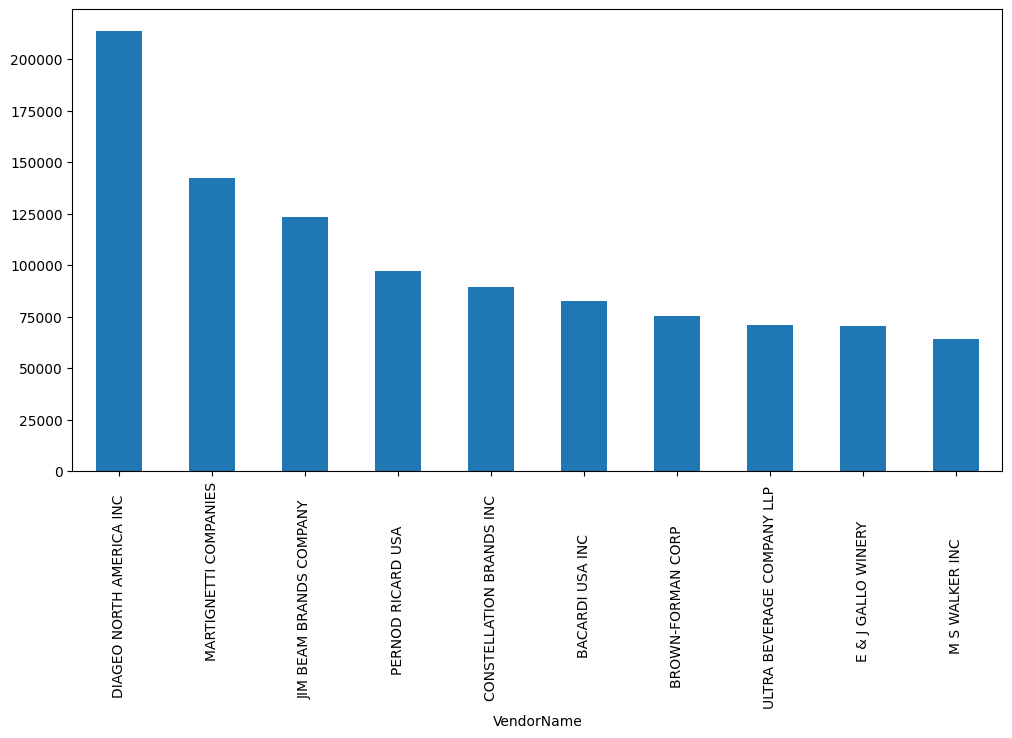

In [ ]:
top_vendors.head(10).plot(kind='bar', figsize=(12,6))

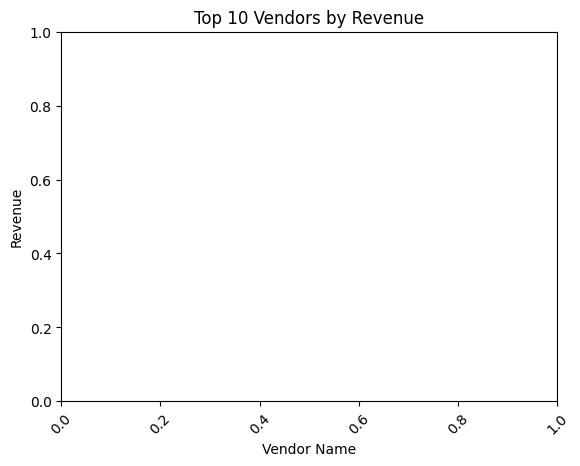

In [ ]:
plt.title('Top 10 Vendors by Revenue')
plt.xlabel('Vendor Name')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Business Insight

Top-performing vendors contribute a large percentage of total business revenue, indicating operational dependency on key suppliers.

# Monthly Sales Trend Analysis

In [ ]:
monthly_sales = sales.groupby(['Month', 'Month_Name'])['SalesDollars'].sum().reset_index()

In [ ]:
monthly_sales = monthly_sales.sort_values('Month')

In [ ]:
monthly_sales

,Month,Month_Name,SalesDollars
0,1,January,1561795.03


### Observation

Sales activity appears concentrated within limited monthly periods in the available dataset sample.

In [ ]:
sales['Month_Name'].unique()

array(['January'], dtype=object)

# Product Performance Analysis

In [ ]:
top_products = sales.groupby('Description')['SalesDollars'].sum()

In [ ]:
top_products = top_products.sort_values(ascending=False)

In [ ]:
top_products.head(10)

,SalesDollars
Description,
Jack Daniels No 7 Black,31252.49
Capt Morgan Spiced Rum,27547.91
Jameson Irish Whiskey,22084.59
Grey Goose Vodka,21138.72
Absolut 80 Proof,17696.81
Ketel One Vodka,16092.20
Tito's Handmade Vodka,15528.99
Jim Beam,12540.32
Jagermeister Liqueur,12186.94


<Axes: xlabel='Description'>

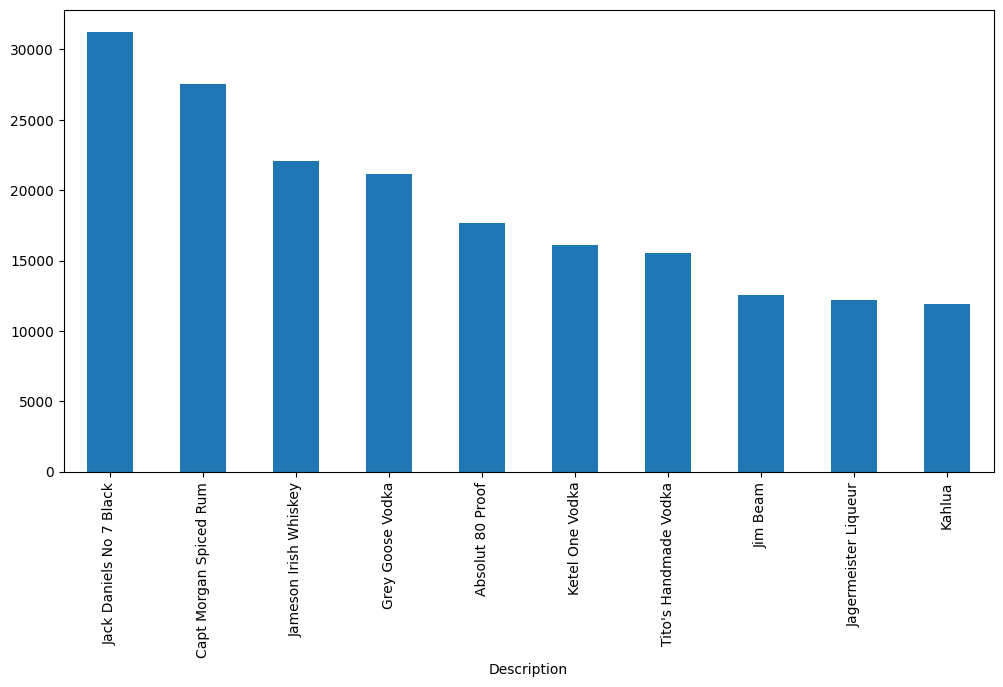

In [ ]:
top_products.head(10).plot(kind='bar', figsize=(12,6))

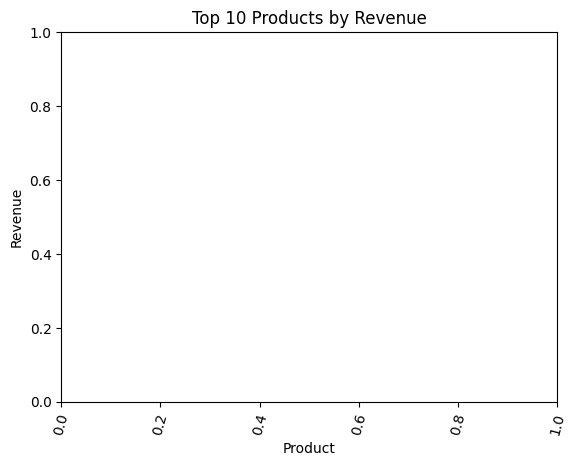

In [ ]:
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=75)
plt.show()

### Business Insight

A limited number of products contribute disproportionately high revenue, indicating strong product concentration patterns.

# Inventory Analysis

In [ ]:
begin_inventory.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8.0,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7.0,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6.0,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3.0,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6.0,34.99,2024-01-01


In [ ]:
end_inventory.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58.0,Gekkeikan Black & Gold Sake,750mL,11.0,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62.0,Herradura Silver Tequila,750mL,7.0,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63.0,Herradura Reposado Tequila,750mL,7.0,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72.0,No. 3 London Dry Gin,750mL,4.0,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75.0,Three Olives Tomato Vodka,750mL,7.0,14.99,2024-12-31


In [ ]:
begin_inventory['InventoryValue'] = begin_inventory['onHand'] * begin_inventory['Price']

In [ ]:
end_inventory['InventoryValue'] = end_inventory['onHand'] * end_inventory['Price']

In [ ]:
print("Beginning Inventory Value:",
      begin_inventory['InventoryValue'].sum())

Beginning Inventory Value: 24575572.06


In [ ]:
print("Ending Inventory Value:",
      end_inventory['InventoryValue'].sum())

Ending Inventory Value: 21433225.81


### Inventory Observation

The organization maintains high inventory value across operations, emphasizing the importance of inventory turnover optimization.

In [ ]:
inventory_comparison = begin_inventory[['InventoryId', 'Description', 'onHand']].copy()

In [ ]:
inventory_comparison.rename(columns={'onHand':'Beginning_Stock'}, inplace=True)

In [ ]:
inventory_comparison['Ending_Stock'] = end_inventory['onHand']

In [ ]:
inventory_comparison['Stock_Movement'] = (
    inventory_comparison['Beginning_Stock']
    - inventory_comparison['Ending_Stock']
)

# Fast-Moving Inventory Analysis

In [ ]:
fast_moving = inventory_comparison.sort_values(
    by='Stock_Movement',
    ascending=False
)

In [ ]:
fast_moving[['Description', 'Stock_Movement']].head(10)

,Description,Stock_Movement
74815,Yukon Jack,696.0
75125,Pinnacle Vodka,544.0
45031,Smirnoff Citrus Vodka,530.0
75294,Ketel One Vodka,492.0
23950,Smirnoff 80 Proof,467.0
53151,Ketel One Vodka,441.0
7532,Dr McGillicuddy's Mentholmnt,414.0
23935,Absolut 80 Proof,385.0
22383,Jack Daniels No 7 Black,384.0
7996,DK Burst Blustery Peppermint,382.0


In [ ]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
fast_moving_top10 = fast_moving.head(10)

<BarContainer object of 10 artists>

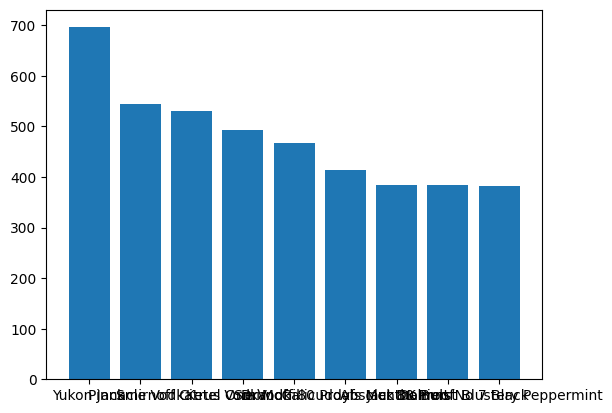

In [ ]:
plt.bar(
    fast_moving_top10['Description'],
    fast_moving_top10['Stock_Movement']
)

Text(0.5, 1.0, 'Top 10 Fast-Moving Products')

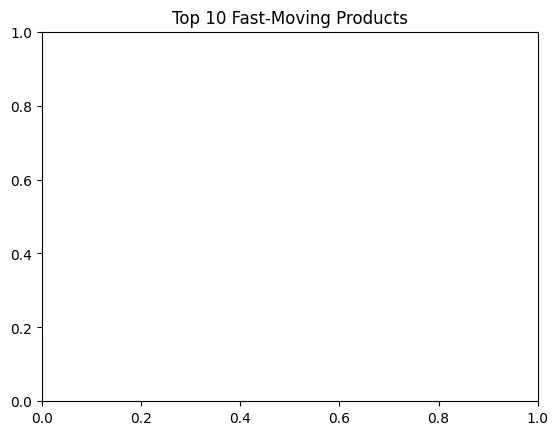

In [ ]:
plt.title('Top 10 Fast-Moving Products')

Text(0, 0.5, 'Stock Movement')

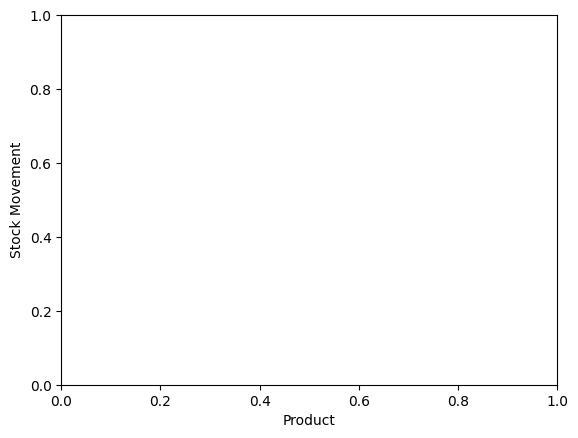

In [ ]:
plt.xlabel('Product')
plt.ylabel('Stock Movement')

### Business Insight

Fast-moving products indicate strong market demand and efficient inventory turnover.

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

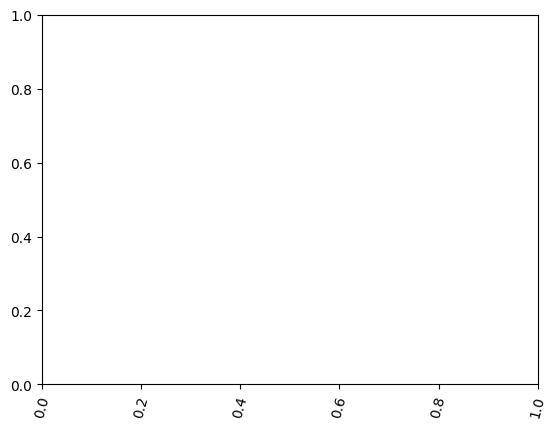

In [ ]:
plt.xticks(rotation=75)

In [ ]:
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0, 0.5, 'Stock Movement')

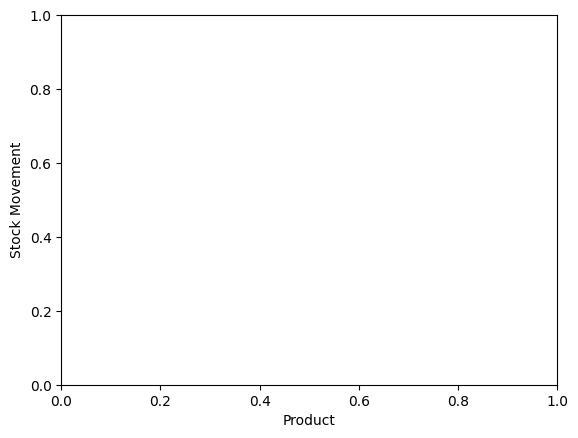

In [ ]:
plt.xlabel('Product')
plt.ylabel('Stock Movement')

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

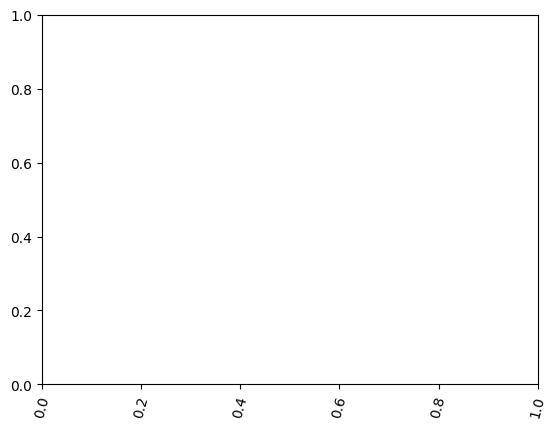

In [ ]:
plt.xticks(rotation=75)

In [ ]:
plt.show()

# Slow-Moving Inventory Analysis

In [ ]:
slow_moving = inventory_comparison.sort_values(
    by='Stock_Movement',
    ascending=True
)

In [ ]:
slow_moving[['Description', 'Stock_Movement']].head(10)

,Description,Stock_Movement
51010,Freixenet Cordon Negro Extr,-1035.0
63272,Tribuno Sweet Vermouth,-876.0
33825,Greg Norman Limestone Shiraz,-778.0
52106,Schmitt Sohne Relax Mosel,-711.0
51834,Dynamite Cab Svgn N Cst,-598.0
35503,RumChata Liqueur,-536.0
34367,Remy Martin XO Excelence VAP,-527.0
266,Jack Daniels Tennessee Honey,-460.0
45857,Banfi Chianti Clsc RSV,-431.0
23603,P & J Cold Soaked Peaches,-414.0


In [ ]:
inventory_comparison['Ending_Stock'] = end_inventory['onHand']

In [ ]:
inventory_comparison['Stock_Movement'] = (
    inventory_comparison['Beginning_Stock']
    - inventory_comparison['Ending_Stock']
)

In [ ]:
inventory_comparison.rename(
    columns={'onHand':'Beginning_Stock'},
    inplace=True
)

In [ ]:
slow_moving = inventory_comparison.sort_values(
    by='Stock_Movement',
    ascending=True
)

slow_moving[['Description', 'Stock_Movement']].head(10)

,Description,Stock_Movement
125032,Gekkeikan Sake,-3667
174585,A Bichot Chard Bourgogne,-2983
125033,Andre Extra Dry,-1721
125030,Manischewitz Blackberry Kshr,-1682
123536,Layer Cake Centrl Cst Pnt Nr,-1576
125473,Rosemount Diamond Merlot,-1264
123623,Phillipine de St-Cyrille CdP,-1244
124246,Crown Royal Regal Apple,-1217
125634,Fat Bastard Chard,-1213
123923,Mirassou Pnt Nr Cntrl Coast,-1187


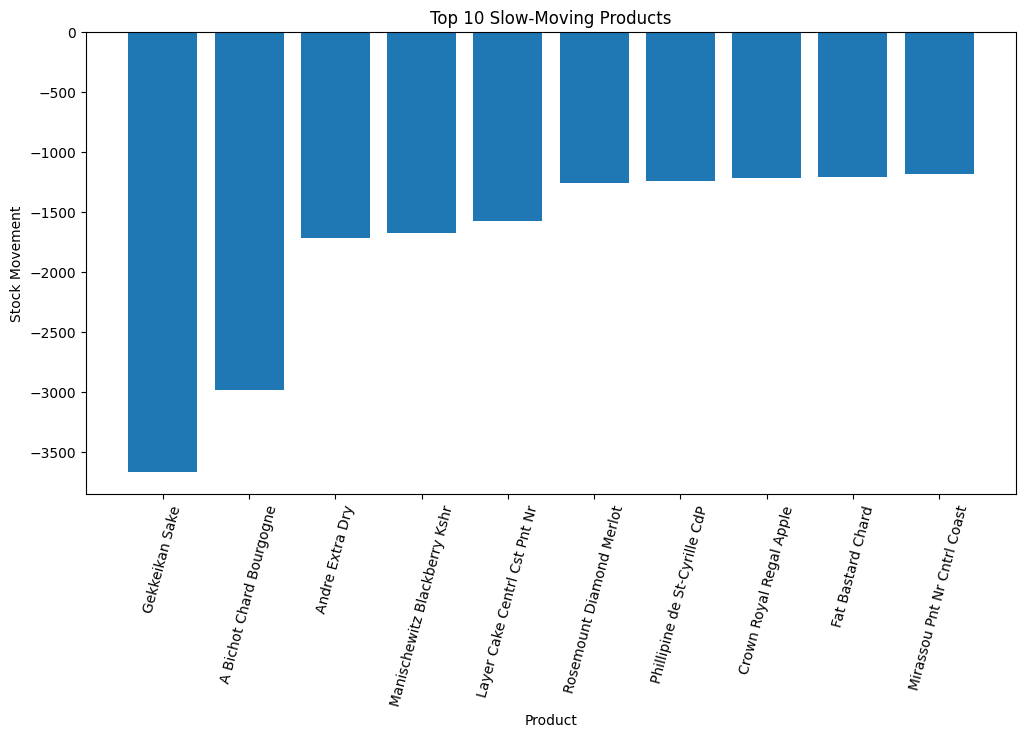

In [ ]:
slow_moving_top10 = slow_moving.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    slow_moving_top10['Description'],
    slow_moving_top10['Stock_Movement']
)

plt.title('Top 10 Slow-Moving Products')

plt.xlabel('Product')

plt.ylabel('Stock Movement')

plt.xticks(rotation=75)

plt.show()

### Business Risk

Slow-moving products may increase holding costs, storage utilization, and inventory inefficiencies.

In [ ]:
inventory_comparison = begin_inventory[
    ['InventoryId', 'Description', 'onHand']
].copy()

### Business Risk

Slow-moving inventory may increase storage costs and operational inefficiencies.

In [ ]:
vendor_contribution = (
    sales.groupby('VendorName')['SalesDollars']
    .sum()
    / sales['SalesDollars'].sum()
) * 100

In [ ]:
vendor_contribution = vendor_contribution.sort_values(
    ascending=False
)

In [ ]:
vendor_contribution.head(10)

,SalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,13.667230
MARTIGNETTI COMPANIES,9.106229
JIM BEAM BRANDS COMPANY,7.888374
PERNOD RICARD USA,6.235004
CONSTELLATION BRANDS INC,5.710852
BACARDI USA INC,5.297719
BROWN-FORMAN CORP,4.818389
ULTRA BEVERAGE COMPANY LLP,4.552595
E & J GALLO WINERY,4.519563


In [ ]:
vendor_contribution = (
    sales.groupby('VendorName')['SalesDollars']
    .sum()
    / sales['SalesDollars'].sum()
) * 100

vendor_contribution = vendor_contribution.sort_values(
    ascending=False
)

vendor_contribution.head(10)

,SalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,14.815107
MARTIGNETTI COMPANIES,8.948096
JIM BEAM BRANDS COMPANY,7.548384
PERNOD RICARD USA,6.763780
CONSTELLATION BRANDS INC,5.251380
BACARDI USA INC,4.991271
E & J GALLO WINERY,4.429848
BROWN-FORMAN CORP,4.207704
ULTRA BEVERAGE COMPANY LLP,4.149242


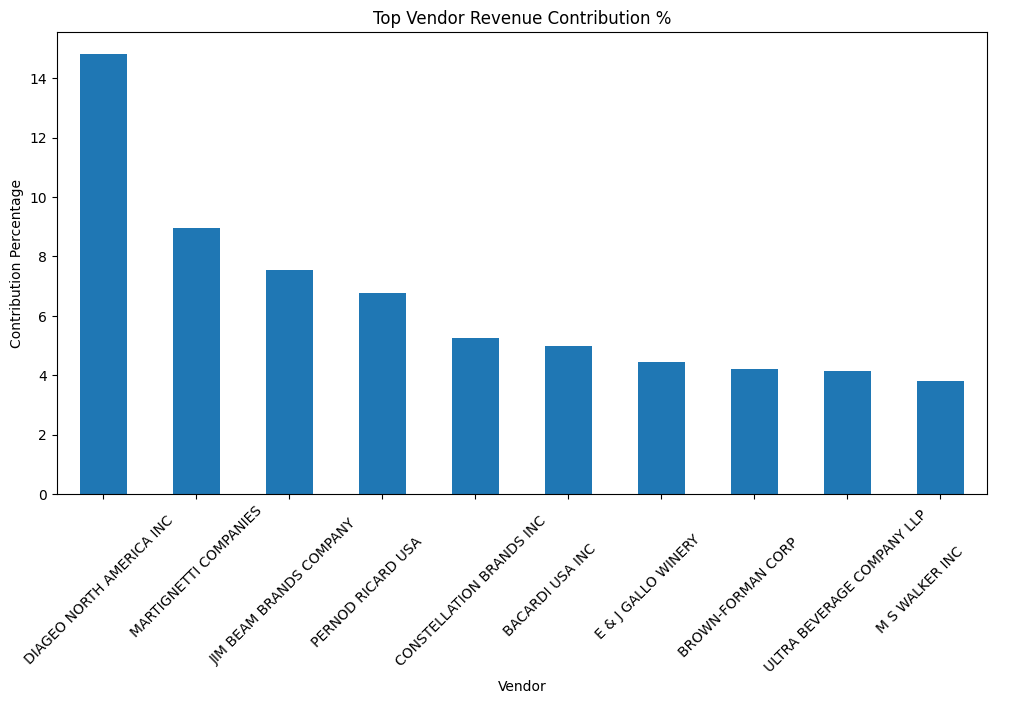

In [ ]:
vendor_contribution.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top Vendor Revenue Contribution %')

plt.xlabel('Vendor')

plt.ylabel('Contribution Percentage')

plt.xticks(rotation=45)

plt.show()

# Store Performance Analysis

In [ ]:
store_performance = sales.groupby('Store')['SalesDollars'].sum()

In [ ]:
store_performance = store_performance.sort_values(
    ascending=False
)

In [ ]:
store_performance.head(10)

,SalesDollars
Store,
10,581298.02
1,496657.18
11,423772.21
12,60067.62


<Axes: xlabel='Store'>

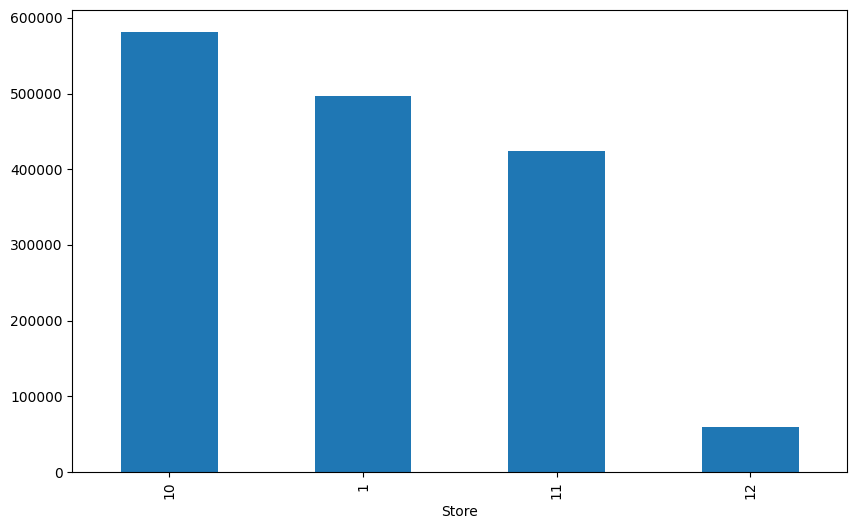

In [ ]:
store_performance.plot(kind='bar', figsize=(10,6))

Text(0.5, 1.0, 'Store Revenue Performance')

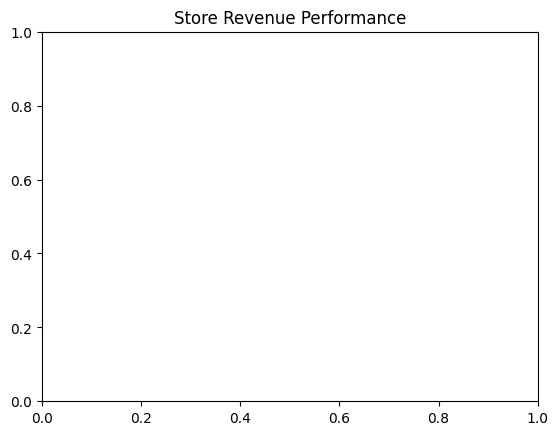

In [ ]:
plt.title('Store Revenue Performance')

Text(0, 0.5, 'Revenue')

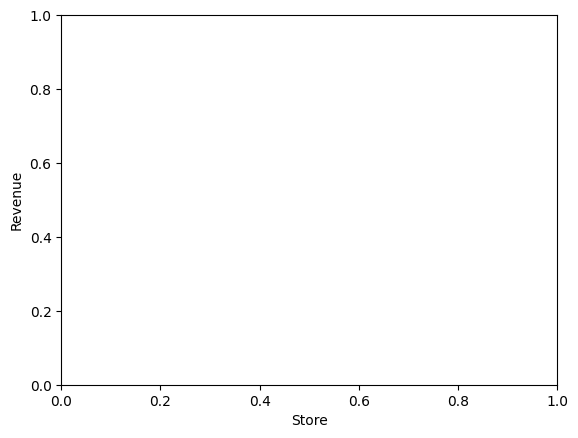

In [ ]:
plt.xlabel('Store')
plt.ylabel('Revenue')

### Business Insight

Certain stores significantly outperform others in revenue generation, indicating uneven operational performance.

In [ ]:
plt.show()

In [ ]:
print(sales.shape)
print(purchases.shape)
print(begin_inventory.shape)
print(end_inventory.shape)
print(purchase_prices.shape)
print(vendor_invoice.shape)

(42250, 14)
(34589, 16)
(75593, 9)
(75474, 9)
(12261, 9)
(5543, 10)


# Procurement & Purchase Analysis

In [ ]:
purchases.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105.0,ALTAMAR BRANDS LLC,8124.0,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6.0,214.26,1.0
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466.0,AMERICAN VINTAGE BEVERAGE,8137.0,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4.0,37.40,1.0
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466.0,AMERICAN VINTAGE BEVERAGE,8137.0,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5.0,47.05,1.0
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466.0,AMERICAN VINTAGE BEVERAGE,8137.0,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6.0,56.10,1.0
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388.0,ATLANTIC IMPORTING COMPANY,8169.0,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5.0,106.60,1.0


In [ ]:
print("Total Purchase Spending:", purchases['Dollars'].sum())

Total Purchase Spending: 5353279.600000001


### Procurement Insight

The business invests heavily in procurement operations, highlighting the importance of vendor efficiency and purchase optimization.

In [ ]:
top_purchase_vendors = (
    purchases.groupby('VendorName')['Dollars']
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
top_purchase_vendors.head(10)

,Dollars
VendorName,
DIAGEO NORTH AMERICA INC,1135099.08
JIM BEAM BRANDS COMPANY,711582.44
MARTIGNETTI COMPANIES,643378.13
BACARDI USA INC,534089.91
BROWN-FORMAN CORP,364306.46
CONSTELLATION BRANDS INC,308650.75
M S WALKER INC,304990.36
E & J GALLO WINERY,295473.38
PERNOD RICARD USA,80916.64


In [ ]:
top_purchase_vendors = (
    purchases.groupby('VendorName')['Dollars']
    .sum()
    .sort_values(ascending=False)
)

top_purchase_vendors.head(10)

,Dollars
VendorName,
DIAGEO NORTH AMERICA INC,17545155.51
JIM BEAM BRANDS COMPANY,8711768.53
MARTIGNETTI COMPANIES,8540284.86
PERNOD RICARD USA,7652710.03
CONSTELLATION BRANDS INC,5621502.96
BACARDI USA INC,5514003.73
BROWN-FORMAN CORP,4852591.12
ULTRA BEVERAGE COMPANY LLP,4543709.71
E & J GALLO WINERY,4527363.16


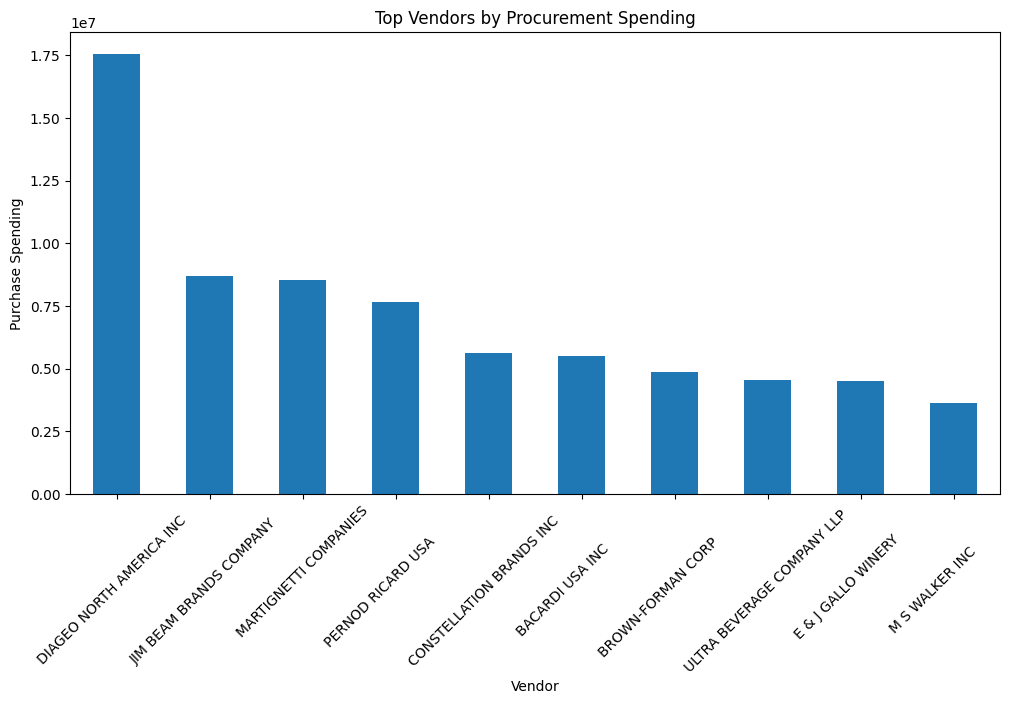

In [ ]:
top_purchase_vendors.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top Vendors by Procurement Spending')
plt.xlabel('Vendor')

plt.ylabel('Purchase Spending')

plt.xticks(rotation=45)

plt.show()

### Business Insight

A small number of vendors contribute a major share of total revenue, indicating concentration dependency in procurement and supply operations.

In [ ]:
sales_vendor_revenue = (
    sales.groupby('VendorName')['SalesDollars']
    .sum()
)

In [ ]:
purchase_vendor_cost = (
    purchases.groupby('VendorName')['Dollars']
    .sum()
)

# Vendor Profitability Analysis

In [ ]:
vendor_comparison = pd.DataFrame({
    'Revenue': sales_vendor_revenue,
    'Purchase_Cost': purchase_vendor_cost
})

vendor_comparison.head()

,Revenue,Purchase_Cost
VendorName,,
ALTAMAR BRANDS LLC,84.94,642.78
AMERICAN VINTAGE BEVERAGE,402.69,3282.88
APPOLO VINEYARDS LLC,NaN,124.80
ATLANTIC IMPORTING COMPANY,258.93,2132.00
BACARDI USA INC,69408.90,534089.91


In [ ]:
vendor_comparison['Estimated_Profit'] = (
    vendor_comparison['Revenue']
    - vendor_comparison['Purchase_Cost']
)

In [ ]:
vendor_comparison = vendor_comparison.sort_values(
    by='Estimated_Profit',
    ascending=True
)

vendor_comparison.head(10)

,Revenue,Purchase_Cost,Estimated_Profit
VendorName,,,
DIAGEO NORTH AMERICA INC,188801.68,1135099.08,-946297.40
JIM BEAM BRANDS COMPANY,108935.70,711582.44,-602646.74
MARTIGNETTI COMPANIES,113875.50,643378.13,-529502.63
BACARDI USA INC,69408.90,534089.91,-464681.01
BROWN-FORMAN CORP,67373.85,364306.46,-296932.61
M S WALKER INC,55054.44,304990.36,-249935.92
CONSTELLATION BRANDS INC,68761.06,308650.75,-239889.69
E & J GALLO WINERY,62388.11,295473.38,-233085.27
CAMPARI AMERICA,14599.44,74513.27,-59913.83


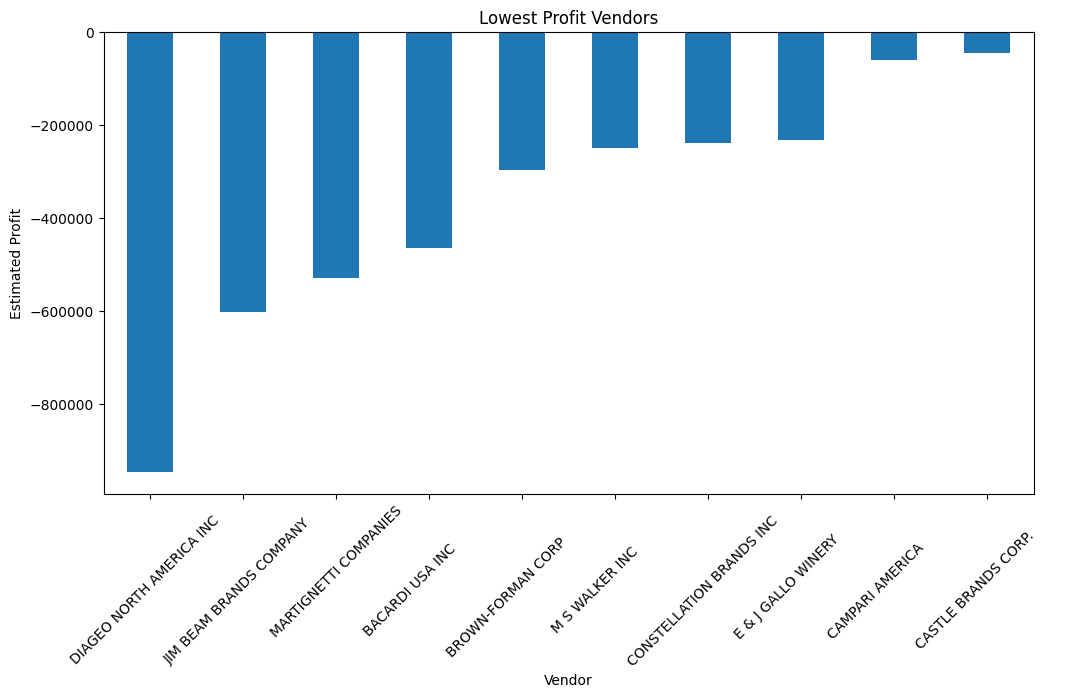

In [ ]:
vendor_comparison.head(10)['Estimated_Profit'].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Lowest Profit Vendors')
plt.xlabel('Vendor')
plt.ylabel('Estimated Profit')
plt.xticks(rotation=45)


plt.show()


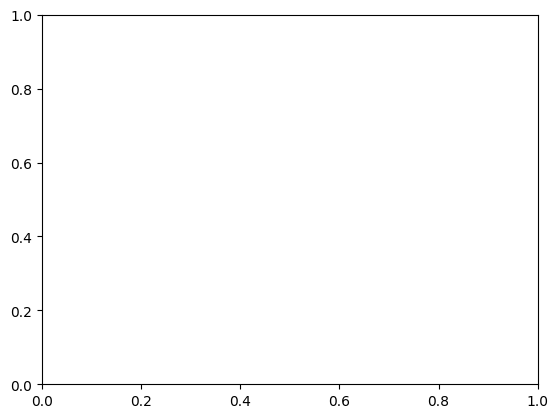

In [ ]:
plt.ticklabel_format(style='plain', axis='y')

### Business Insight

Some vendors generate low estimated profitability despite high procurement costs, suggesting pricing inefficiencies or low-margin operations.

In [ ]:
vendor_comparison = vendor_comparison.sort_values(
    by='Estimated_Profit',
    ascending=True
)

vendor_comparison.head(10)

,Revenue,Purchase_Cost,Estimated_Profit
VendorName,,,
DIAGEO NORTH AMERICA INC,188801.68,1135099.08,-946297.40
JIM BEAM BRANDS COMPANY,108935.70,711582.44,-602646.74
MARTIGNETTI COMPANIES,113875.50,643378.13,-529502.63
BACARDI USA INC,69408.90,534089.91,-464681.01
BROWN-FORMAN CORP,67373.85,364306.46,-296932.61
M S WALKER INC,55054.44,304990.36,-249935.92
CONSTELLATION BRANDS INC,68761.06,308650.75,-239889.69
E & J GALLO WINERY,62388.11,295473.38,-233085.27
CAMPARI AMERICA,14599.44,74513.27,-59913.83


In [ ]:
(vendor_comparison['Estimated_Profit'] > 0).value_counts()

,count
Estimated_Profit,
False,76
True,25


In [ ]:
monthly_sales = sales.groupby(
    sales['SalesDate'].dt.month
)['SalesDollars'].sum()

In [ ]:
monthly_sales

,SalesDollars
SalesDate,
1,1318668.95


In [ ]:
vendor_contribution = (
    sales.groupby('VendorName')['SalesDollars']
    .sum()
    / sales['SalesDollars'].sum()
) * 100

vendor_contribution = vendor_contribution.sort_values(
    ascending=False
)

vendor_contribution.head(5)

,SalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,14.317595
MARTIGNETTI COMPANIES,8.635640
JIM BEAM BRANDS COMPANY,8.261035
PERNOD RICARD USA,6.362994
BACARDI USA INC,5.263558


# Feature Engineering

In [ ]:
sales['Revenue_Per_Unit'] = (
    sales['SalesDollars']
    / sales['SalesQuantity']
)

# High-Value Product Analysis

In [ ]:
high_value_products = sales.groupby(
    'Description'
)['Revenue_Per_Unit'].mean()

high_value_products = high_value_products.sort_values(
    ascending=False
)

high_value_products.head(10)

,Revenue_Per_Unit
Description,
The Macallan Rare Cask,299.99
The Macallan 18 Yr Old,259.99
Johnnie Walker Blue Label,242.99
Balvenie Portwood 21 Yr Sin,219.99
Hennessy XO Cognac,199.99
Jack Daniels Sinatra Select,165.99
Remy Martin XO Cognac,159.99
Midleton Rare Irish Whiskey,154.99
Courvoisier XO Cognac,149.99


### Business Insight

Premium products generate higher revenue per unit and contribute significantly to profitability optimization opportunities.

In [ ]:
high_purchase_vendors = purchases.groupby(
    'VendorName'
)['Quantity'].sum()

high_purchase_vendors = high_purchase_vendors.sort_values(
    ascending=False
)

high_purchase_vendors.head(10)

,Quantity
VendorName,
DIAGEO NORTH AMERICA INC,116785.0
JIM BEAM BRANDS COMPANY,67824.0
MARTIGNETTI COMPANIES,58475.0
E & J GALLO WINERY,45077.0
CONSTELLATION BRANDS INC,45009.0
BACARDI USA INC,42563.0
M S WALKER INC,38449.0
BROWN-FORMAN CORP,28035.0
CAMPARI AMERICA,9983.0


# Product Demand Analysis

In [ ]:
top_demand_products = sales.groupby(
    'Description'
)['SalesQuantity'].sum()

top_demand_products = top_demand_products.sort_values(
    ascending=False
)

top_demand_products.head(10)

,SalesQuantity
Description,
Smirnoff 80 Proof,1747
Capt Morgan Spiced Rum,1436
Jack Daniels No 7 Black,1138
Jim Beam,1030
Smirnoff Raspberry Vodka,971
Bacardi Superior Rum,969
Yukon Jack,906
Tito's Handmade Vodka,894
Smirnoff Vanilla Vodka,892


### Demand Insight

High-demand products demonstrate strong customer purchasing behavior and inventory consumption patterns.

# Overstock & Remaining Inventory Analysis


In [ ]:
high_remaining_stock = end_inventory.groupby(
    'Description'
)['onHand'].sum()

high_remaining_stock = high_remaining_stock.sort_values(
    ascending=False
)

high_remaining_stock.head(10)

,onHand
Description,
Absolut 80 Proof,10811.0
Capt Morgan Spiced Rum,10776.0
Jack Daniels No 7 Black,10439.0
Bacardi Superior Rum,9645.0
Grey Goose Vodka,9371.0
Jim Beam,8915.0
Smirnoff 80 Proof,8833.0
Jameson Irish Whiskey,8735.0
Ketel One Vodka,8422.0


### Inventory Risk

Products with extremely high remaining inventory levels may indicate overstocking risks or slower market demand.

In [ ]:
top_demand_products.head(10)

,SalesQuantity
Description,
Smirnoff 80 Proof,1747
Capt Morgan Spiced Rum,1436
Jack Daniels No 7 Black,1138
Jim Beam,1030
Smirnoff Raspberry Vodka,971
Bacardi Superior Rum,969
Yukon Jack,906
Tito's Handmade Vodka,894
Smirnoff Vanilla Vodka,892


In [ ]:
vendor_revenue_ranking = sales.groupby(
    'VendorName'
)['SalesDollars'].sum()

vendor_revenue_ranking = vendor_revenue_ranking.sort_values(
    ascending=False
)

vendor_revenue_ranking.head(10)

,SalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,188801.68
MARTIGNETTI COMPANIES,113875.50
JIM BEAM BRANDS COMPANY,108935.70
PERNOD RICARD USA,83906.82
BACARDI USA INC,69408.90
CONSTELLATION BRANDS INC,68761.06
BROWN-FORMAN CORP,67373.85
E & J GALLO WINERY,62388.11
ULTRA BEVERAGE COMPANY LLP,58979.76


# KPI Engineering

In [ ]:
total_revenue = sales['SalesDollars'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1318668.9500000002


### KPI Observation

The business generated significant revenue volume across thousands of sales transactions, indicating large-scale operational activity suitable for enterprise analytics.

# Duplicate Record Analysis

In [ ]:
print("Sales Duplicates:", sales.duplicated().sum())

print("Purchases Duplicates:", purchases.duplicated().sum())

print("Begin Inventory Duplicates:", begin_inventory.duplicated().sum())

print("End Inventory Duplicates:", end_inventory.duplicated().sum())

Sales Duplicates: 0
Purchases Duplicates: 0
Begin Inventory Duplicates: 0
End Inventory Duplicates: 0


### Data Integrity Observation

Duplicate validation ensures accurate KPI calculations, inventory tracking, and transactional consistency within analytical workflows.

# Outlier Analysis

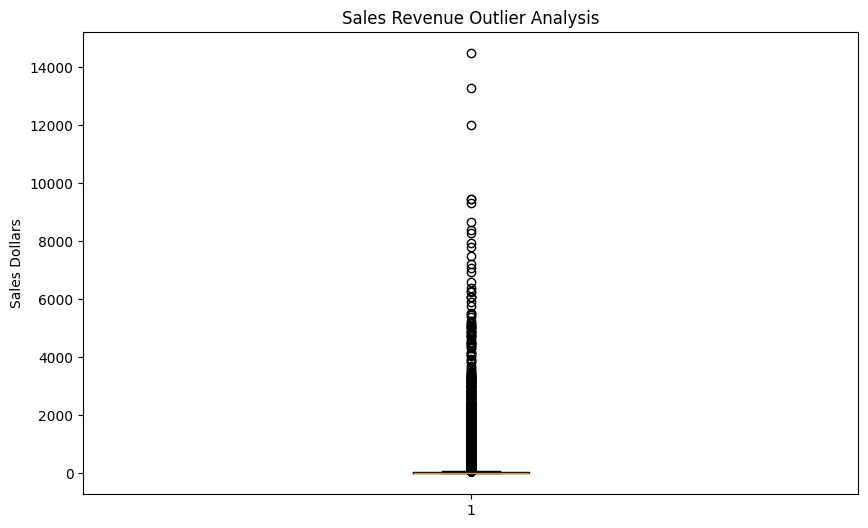

In [ ]:
plt.figure(figsize=(10,6))

plt.boxplot(sales['SalesDollars'])

plt.title('Sales Revenue Outlier Analysis')

plt.ylabel('Sales Dollars')

plt.show()

### Business Insight

Several extreme sales values exist within the dataset, indicating the presence of high-value transactions and premium product sales.

# Correlation Analysis

In [ ]:
correlation = sales[
    ['SalesQuantity', 'SalesDollars', 'SalesPrice']
].corr()

correlation

,SalesQuantity,SalesDollars,SalesPrice
SalesQuantity,1.000000,0.633935,-0.085547
SalesDollars,0.633935,1.000000,0.341117
SalesPrice,-0.085547,0.341117,1.000000


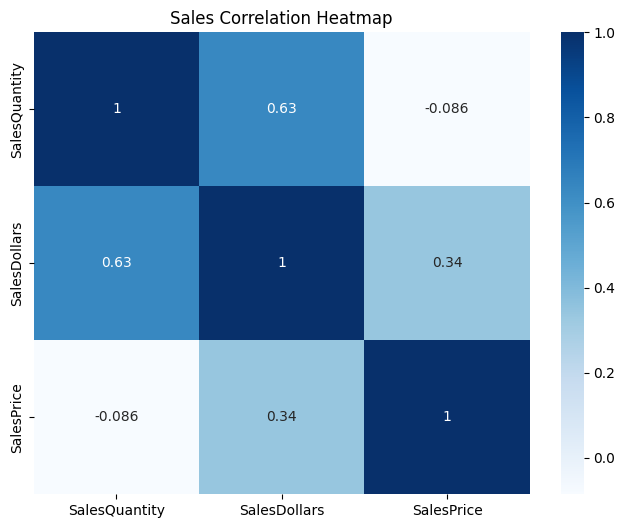

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='Blues')

plt.title('Sales Correlation Heatmap')

plt.show()

### Business Insight

Positive correlation between sales quantity and revenue highlights demand-driven business growth patterns.

# Executive Summary

## Major Findings

- Top vendors contribute major revenue share, indicating supplier dependency.
- Several products demonstrate high inventory turnover and strong market demand.
- Certain vendors generate low profitability despite high procurement costs.
- Overstocked products may increase operational storage costs.
- Store performance varies significantly across locations.

---

## Business Recommendations

- Reduce dependency on limited vendors.
- Optimize slow-moving inventory.
- Improve procurement cost efficiency.
- Focus marketing efforts on high-demand products.
- Monitor profitability across vendor relationships.

---

## Future Scope

- Power BI Dashboard Development
- SQL Business Intelligence Layer
- Forecasting & Predictive Analytics
- Automated ETL Pipelines
- Recommendation Engine

# Conclusion

This project successfully analyzed vendor, sales, inventory, procurement, and profitability performance using Python-based business intelligence techniques. The notebook demonstrates end-to-end exploratory data analysis, KPI engineering, inventory analytics, vendor performance evaluation, and operational insight generation suitable for enterprise-level analytical workflows.